In [6]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import seaborn as sns
from importlib import reload
import warnings
import healpy as hp
import collections
from collections import namedtuple

sys.path.insert(0,'../../scripts/tools_for_VAE/')
from tools_for_VAE import cutout_img_dc2
from tools_for_VAE import plot, utils, generator

import galsim

from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.visualization import ZScaleInterval
from astropy.table import Table
from sklearn import preprocessing

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [7]:
%matplotlib inline

plt.rcParams['figure.figsize'] = (6, 6)
zscale = ZScaleInterval()

## Load data to modify

In [53]:
x_1_temp = np.load('/pbs/home/b/barcelin/sps_link/data/dc2_test/training_mag_24.5/3_img_sample.npy', mmap_mode = 'c')
x_2_temp = np.load('/pbs/home/b/barcelin/sps_link/data/dc2_test/training_mag_24.5/3_psf_sample.npy', mmap_mode = 'c')
data = pd.read_csv('/pbs/home/b/barcelin/sps_link/data/dc2_test/training_mag_24.5/3_img_data.csv')

bands = [0,1,2,3,4,5]

In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   e1             10000 non-null  float64
 2   e2             10000 non-null  float64
 3   shear_1        10000 non-null  float64
 4   shear_2        10000 non-null  float64
 5   redshift       10000 non-null  float64
 6   redshift_true  10000 non-null  float64
 7   blendedness    10000 non-null  float64
 8   snr_r          9999 non-null   float64
 9   convergence    10000 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 781.4 KB


In [56]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

In [57]:
new_data = data[(np.abs(data['e1'])<=1.) &
                (np.abs(data['e2'])<=1.)]

ell_1 = np.array(new_data['e1'][:])
ell_2 = np.array(new_data['e2'][:])
shear_1 = np.array(new_data['shear_1'][:])
shear_2 = np.array(new_data['shear_2'][:])
convergence = np.array(new_data['convergence'][:])

ellipticity = calc_lensed_ellipticity(ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

#ellipticity_1 = ellipticity_conversion(calc_lensed_ellipticity_1(ell_1, ell_2, shear_1, shear_2, convergence))
#ellipticity_2 = ellipticity_conversion(calc_lensed_ellipticity_2(ell_1, ell_2, shear_1, shear_2, convergence))
ellipticity_1 = calc_lensed_ellipticity_1(ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity_2 = calc_lensed_ellipticity_2(ell_1, ell_2, shear_1, shear_2, convergence)

In [58]:
interp = 'lanczos15'
#fwhm_lsst = [1.3,1.3,1.3,1.3,1.3,1.3]# Max of PSF for all bands
fwhm_lsst = [1.01, 0.98, 0.92, 0.85, 0.98, 1.22] ## Max of PSF in all bands
PSF_lsst = [galsim.Kolmogorov(fwhm=fwhm_lsst[k]) for k in range (6)]
#print(PSF_lsst)

x_1_deconv = np.zeros((len(ellipticity_1),59,59,len(bands)))
x_1 = np.zeros((len(ellipticity_1),59,59,len(bands)))
x_2 = np.zeros((len(ellipticity_1),59,59,len(bands)))
y = np.zeros((len(ellipticity_1), 2))

In [59]:
galsim_img = galsim.ImageF(59, 59, scale=0.2)
for i in range (len(ellipticity_1)):
    print(i)
    try:
        for j in range (len(bands)):
            # Deconvolution with galsim
            psf_img = galsim.Image(x_2_temp[i,:,:,j].copy())
            gal_img = galsim.Image(x_1_temp[i,:,:,j].copy())

            psf_int = galsim.InterpolatedImage(psf_img,x_interpolant= interp, scale = 0.2)
            gal_int = galsim.InterpolatedImage(gal_img,x_interpolant= interp, scale = 0.2)
            inv_psf = galsim.Deconvolve(psf_int)
            deconv_gal = galsim.Convolve(inv_psf, gal_int)
            gal = galsim.Convolve(deconv_gal, PSF_lsst[j])
            _ = gal.drawImage(image=galsim_img)
            x_1[i,:,:,j] = galsim_img.array.data
        #i+=1
        x_2[i]=x_2_temp[i]
        y[i,0] = ellipticity_1[i]
        y[i,1] = ellipticity_2[i]
        
    except:
        y[i,0] = 100
        pass
    #break
    print(y[i,0], y[i,1])
#except RuntimeError as e:
#    pass

0
0.018870760283490443 -0.00032612156699405426
1
0.011810965190905203 -0.011411635068032744
2
0.03343700745617659 -0.036163765447553856
3
-0.159245181966705 -0.007324636265601368
4
0.09833086355461786 0.5235307941757645
5
-0.011858314013710661 -0.005768101442930691
6
-0.010733214876264866 0.009642566827476638
7
-0.04372538526824852 -0.1261949951338439
8
-0.07140959632212396 0.04040786887394099
9
0.16657955025369103 0.4781696925539907
10
0.011868796930179061 -0.1046363981957371
11
-0.08681088814262548 0.11416885684499187
12
0.033143425016404514 -0.015382568043789572
13
-0.03953978828181564 -0.10955915039192224
14
0.3047121121279184 0.03724951291709155
15
0.047262847969239394 -0.16951345418126865
16
-0.06746703958495373 0.02075606507030451
17
0.0026741187859219027 -0.0021395838692818566
18
0.01961168548618449 -0.008075849716285747
19
0.014264812841956182 -0.006376716250989818
20
-0.1952762365612032 -0.03054695407110855
21
-0.0939756583052767 0.042860119662935695
22
-0.0027720436294135045

In [8]:
np.where(y[:,0]==100)

(array([ 312,  341,  419,  445,  808,  863, 1330, 1770, 2251, 3255, 3373,
        3445, 3862, 3996, 4204, 4580, 4694, 5123, 5139, 5574, 5689, 6156,
        7601, 8318, 8523, 9200, 9223, 9948]),)

In [9]:
np.where(y[:,0]==np.nan)

(array([], dtype=int64),)

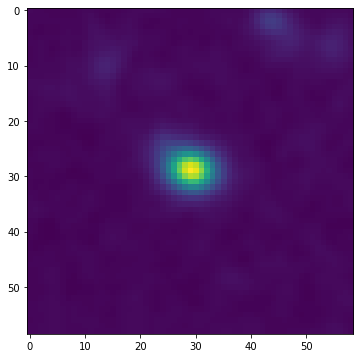

In [10]:
plt.imshow(x_1[9996,:,:,2])

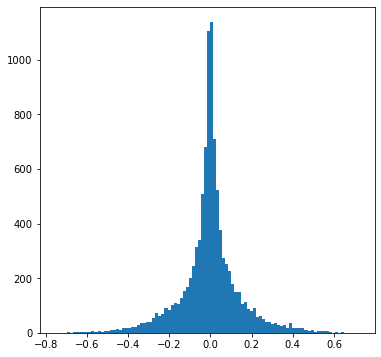

In [11]:
_ = plt.hist(y[:,0], bins = 100)

In [60]:
df = pd.DataFrame()
df['e1']=y[:,0]
df['e2']=y[:,1]
df['shear_1']=data['shear_1']
df['shear_2']=data['shear_2']
df['convergence']=data['convergence']

In [61]:
np.save('/pbs/home/b/barcelin/sps_link/data/dc2_test/deconv_conv_24.5/training/3_img_sample.npy', x_1)
np.save('/pbs/home/b/barcelin/sps_link/data/dc2_test/deconv_conv_24.5/training/3_psf_sample.npy', x_2)
df.to_csv('/pbs/home/b/barcelin/sps_link/data/dc2_test/deconv_conv_24.5/training/3_img_data.csv', index=False)

In [10]:
df = pd.read_csv('/pbs/home/b/barcelin/sps_link/data/dc2_test/deconv_conv_24.5/training/2_img_data.csv')
x_1 = np.load('/pbs/home/b/barcelin/sps_link/data/dc2_test/deconv_conv_24.5/training/2_img_sample.npy', mmap_mode = 'c')
x_2 = np.load('/pbs/home/b/barcelin/sps_link/data/dc2_test/deconv_conv_24.5/training/2_psf_sample.npy', mmap_mode = 'c')

0.012147651306875703 -0.020530832387768157
-0.0392972535466352 0.044342614705161584
-0.15460721858790039 -0.0007856589951065153


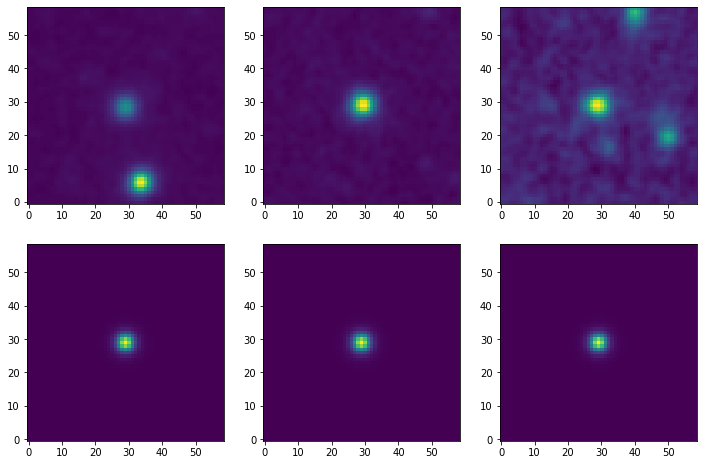

In [27]:
fig, axes = plt.subplots(2,3, figsize = (12,8))

for i in range(3):
    axes[0,i].imshow(x_1[i+15,:,:,2], origin = 'lower')
    axes[1,i].imshow(x_2[i+15,:,:,2], origin = 'lower')
    print(df['e1'][i+15], df['e2'][i+15])


In [39]:
reload(generator)

<module 'tools_for_VAE.generator' from '../../scripts/tools_for_VAE/tools_for_VAE/generator.py'>

In [45]:
images_dir = '/pbs/home/b/barcelin/sps_link/data/dc2_test/deconv_conv_24.5/'

list_of_samples = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'training')) if x.endswith('img_sample.npy')][:1]#mag_24.5
list_of_samples_val = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'validation')) if x.endswith('img_sample.npy')]#mag_24.5
#list_of_samples_test = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'test')) if x.endswith('img_sample.npy')]#mag_24.5
batch_size = 512
print(list_of_samples)
print(list_of_samples_val)
################# With generators
training_generator = generator.BatchGenerator_dc2_deconv_2(bands,
                                    images_dir,
                                    list_of_samples, 
                                    total_sample_size=None,
                                    batch_size=batch_size, 
                                    trainval_or_test='training',
                                    do_norm=False,
                                    denorm = False,
                                    list_of_weights_e=None)

['/pbs/home/b/barcelin/sps_link/data/dc2_test/deconv_conv_24.5/training/2_img_sample.npy']
['/pbs/home/b/barcelin/sps_link/data/dc2_test/deconv_conv_24.5/validation/img_sample.npy']
[BatchGenerator] total_sample_size =  10000
[BatchGenerator] len(list_of_samples) =  1


In [46]:
test = training_generator.__getitem__(1)

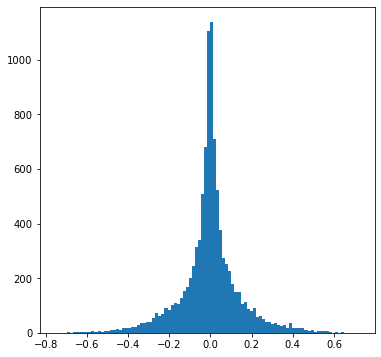

In [72]:
_ = plt.hist(df['e1'], bins = 100)

In [47]:
test[1].shape

(512, 2)

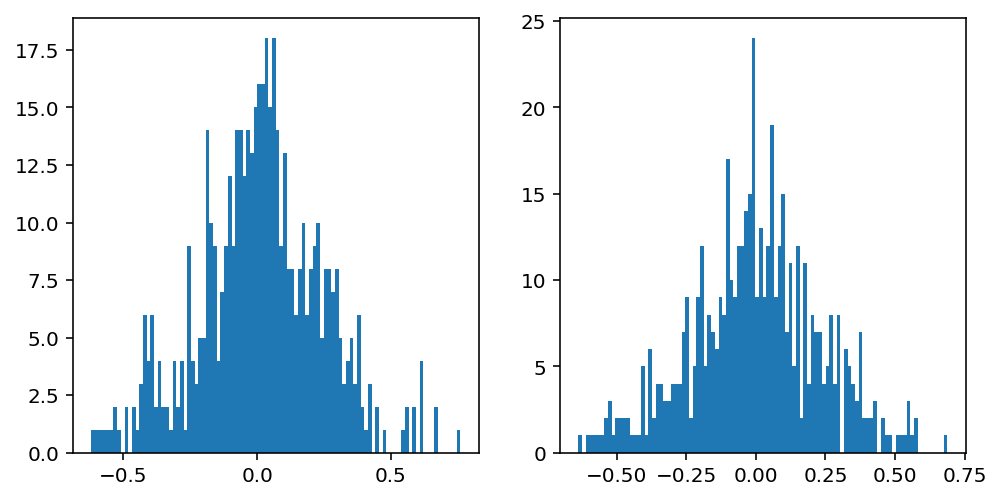

In [49]:
fig, axes = plt.subplots(1,2,figsize = (8,4))
_ = axes[0].hist(test[1][:,0], bins = 100)
_ = axes[1].hist(test[1][:,1], bins = 100)

In [5]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)


In [6]:
data_gen = pd.read_csv('/sps/lsst/users/barcelin/data/dc2_test/deconv_conv_24.5/training/2_img_data.csv')
ell_1_test = np.array(data_gen['e1'])
ell_2_test = np.array(data_gen['e2'])
shear_1_test = np.array(data_gen['shear_1'])
shear_2_test = np.array(data_gen['shear_2'])
convergence_test = np.array(data_gen['convergence'])

ellipticity_1_test = calc_lensed_ellipticity_1(ell_1_test, ell_2_test, shear_1_test, shear_2_test, convergence_test)
ellipticity_2_test = calc_lensed_ellipticity_2(ell_1_test, ell_2_test, shear_1_test, shear_2_test, convergence_test)
quantile_transformer_1 = preprocessing.QuantileTransformer(output_distribution='normal', random_state=0) #
quantile_transformer_1 = quantile_transformer_1.fit(ellipticity_1_test.reshape(-1, 1))
quantile_transformer_2 = preprocessing.QuantileTransformer(output_distribution='normal', random_state=0) #output_distribution='normal',
quantile_transformer_2 = quantile_transformer_2.fit(ellipticity_2_test.reshape(-1, 1))

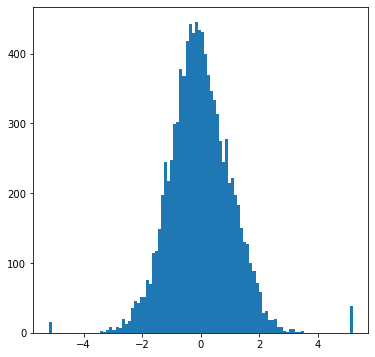

In [9]:
data_gen = pd.read_csv('/sps/lsst/users/barcelin/data/dc2_test/deconv_conv_24.5/validation/img_data.csv')
ell_1_test = np.array(data_gen['e1'])
ell_2_test = np.array(data_gen['e2'])
shear_1_test = np.array(data_gen['shear_1'])
shear_2_test = np.array(data_gen['shear_2'])
convergence_test = np.array(data_gen['convergence'])

ellipticity_1 = calc_lensed_ellipticity_1(ell_1_test, ell_2_test, shear_1_test, shear_2_test, convergence_test)
ellipticity_2 = calc_lensed_ellipticity_2(ell_1_test, ell_2_test, shear_1_test, shear_2_test, convergence_test)

_ = plt.hist(quantile_transformer_1.transform(ellipticity_1.reshape(-1, 1))[:,0], bins = 100)

## Comparison Galsim / DC2 datasets

In [5]:
x_1_temp = np.load('/pbs/home/b/barcelin/sps_link/data/dc2_test/test_mag_24.5/img_sample.npy', mmap_mode = 'c')
x_2_temp = np.load('/pbs/home/b/barcelin/sps_link/data/dc2_test/test_mag_24.5/psf_sample.npy', mmap_mode = 'c')
data_dc2 = pd.read_csv('/pbs/home/b/barcelin/sps_link/data/dc2_test/test_mag_24.5/img_data.csv')

bands = [0,1,2,3,4,5]

In [6]:
data_dc2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              10000 non-null  int64  
 1   e1              10000 non-null  float64
 2   e2              10000 non-null  float64
 3   shear_1         10000 non-null  float64
 4   shear_2         10000 non-null  float64
 5   redshift        10000 non-null  float64
 6   redshift_true   10000 non-null  float64
 7   blendedness     10000 non-null  float64
 8   snr_r           9996 non-null   float64
 9   convergence     10000 non-null  float64
 10  e1_hsm_regauss  9978 non-null   float64
 11  e2_hsm_regauss  9978 non-null   float64
 12  mag_r_meas      9996 non-null   float64
 13  mag_r_true      10000 non-null  float64
dtypes: float64(13), int64(1)
memory usage: 1.1 MB


In [7]:
data_galsim = pd.read_csv('/pbs/home/b/barcelin/sps_link/data/TFP/GalSim_COSMOS/blended_galaxies/random/test/galaxies_blended_20191024_0_data.csv')
data_galsim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   redshift_0                10000 non-null  float64
 1   moment_sigma_0            10000 non-null  float64
 2   e1_0                      10000 non-null  float64
 3   e2_0                      10000 non-null  float64
 4   mag_0                     10000 non-null  float64
 5   redshift_1                10000 non-null  float64
 6   moment_sigma_1            10000 non-null  float64
 7   e1_1                      10000 non-null  float64
 8   e2_1                      10000 non-null  float64
 9   mag_1                     10000 non-null  float64
 10  redshift_2                10000 non-null  float64
 11  moment_sigma_2            10000 non-null  float64
 12  e1_2                      10000 non-null  float64
 13  e2_2                      10000 non-null  float64
 14  mag_2  

In [8]:
print(len(data_galsim['mag_0']), len(data_dc2['mag_r_meas']))

10000 10000


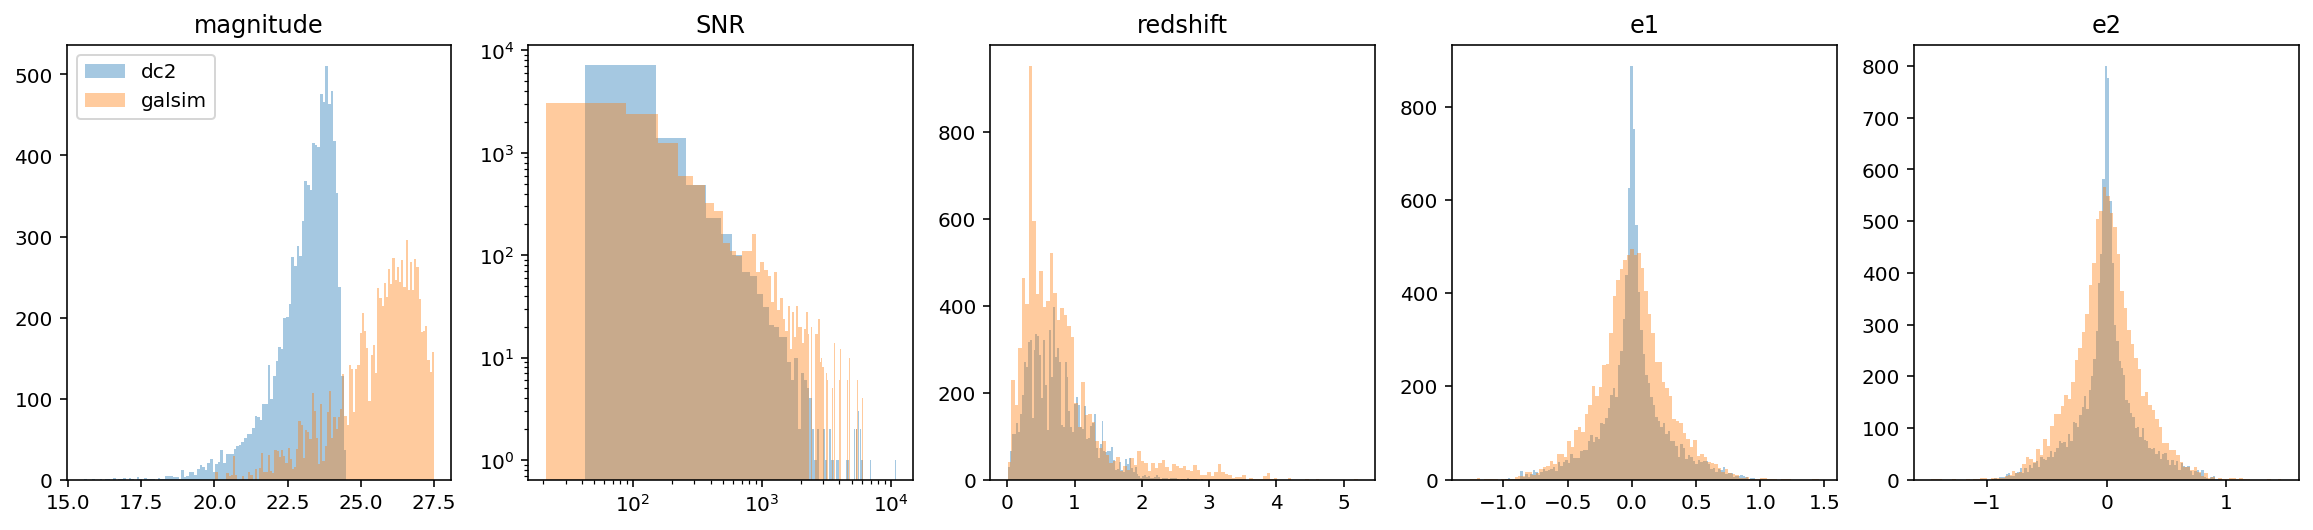

In [9]:
fig, axes = plt.subplots(1,5, figsize = (20,4))
_ = axes[0].hist(data_dc2['mag_r_meas'], bins = 100, alpha = 0.4, label ='dc2')
_ = axes[0].hist(data_galsim['mag_0'], bins = 100, alpha = 0.4, label ='galsim')
axes[0].set_title('magnitude')

_ = axes[1].hist(data_dc2['snr_r'], bins = 100, alpha = 0.4, label ='dc2', log = True)
_ = axes[1].hist(data_galsim['SNR'], bins = 100, alpha = 0.4, label ='galsim', log = True)
axes[1].set_xscale('log')
axes[1].set_title('SNR')

_ = axes[2].hist(data_dc2['redshift'], bins = 100, alpha = 0.4, label ='dc2')
_ = axes[2].hist(data_galsim['redshift_0'], bins = 100, alpha = 0.4, label ='galsim')
axes[2].set_title('redshift')

_ = axes[3].hist(2*(data_dc2['e1']+data_dc2['shear_1'])/(1+data_dc2['e1']**2), bins = 100, alpha = 0.4, label ='dc2')
_ = axes[3].hist(data_galsim['e1_0'], bins = 100, alpha = 0.4, label ='galsim')
axes[3].set_title('e1')

_ = axes[4].hist(2*(data_dc2['e2']+data_dc2['shear_2'])/(1+data_dc2['e2']**2), bins = 100, alpha = 0.4, label ='dc2')
_ = axes[4].hist(data_galsim['e2_0'], bins = 100, alpha = 0.4, label ='galsim')
axes[4].set_title('e2')

axes[0].legend()

In [10]:
np.min(data_dc2['snr_r'])

42.15195152094624

In [19]:
img_galsim = np.load('/pbs/home/b/barcelin/sps_link/data/TFP/GalSim_COSMOS/blended_galaxies/random/test/galaxies_blended_20191024_0_images.npy', mmap_mode = 'c')

In [20]:
img_galsim.shape

(10000, 2, 10, 64, 64)

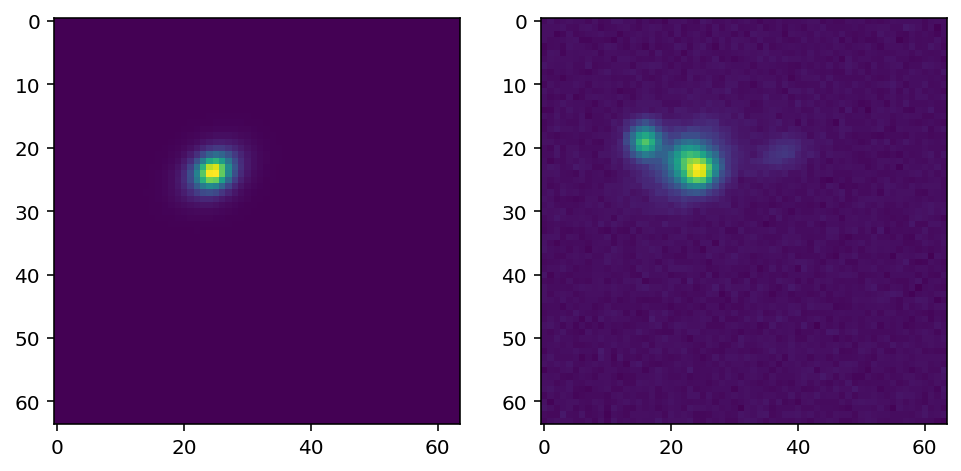

In [21]:
fig, axes = plt.subplots(1,2,figsize =(8,4))
axes[0].imshow(img_galsim[4,0,6])
axes[1].imshow(img_galsim[4,1,6])

In [17]:
check_data = pd.read_csv('/pbs/home/b/barcelin/sps_link/data/TFP/GalSim_COSMOS/blended_galaxies/random/training/galaxies_blended_20191024_9_data.csv')

In [18]:
check_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   redshift_0                10000 non-null  float64
 1   moment_sigma_0            10000 non-null  float64
 2   e1_0                      10000 non-null  float64
 3   e2_0                      10000 non-null  float64
 4   mag_0                     10000 non-null  float64
 5   redshift_1                10000 non-null  float64
 6   moment_sigma_1            10000 non-null  float64
 7   e1_1                      10000 non-null  float64
 8   e2_1                      10000 non-null  float64
 9   mag_1                     10000 non-null  float64
 10  redshift_2                10000 non-null  float64
 11  moment_sigma_2            10000 non-null  float64
 12  e1_2                      10000 non-null  float64
 13  e2_2                      10000 non-null  float64
 14  mag_2  

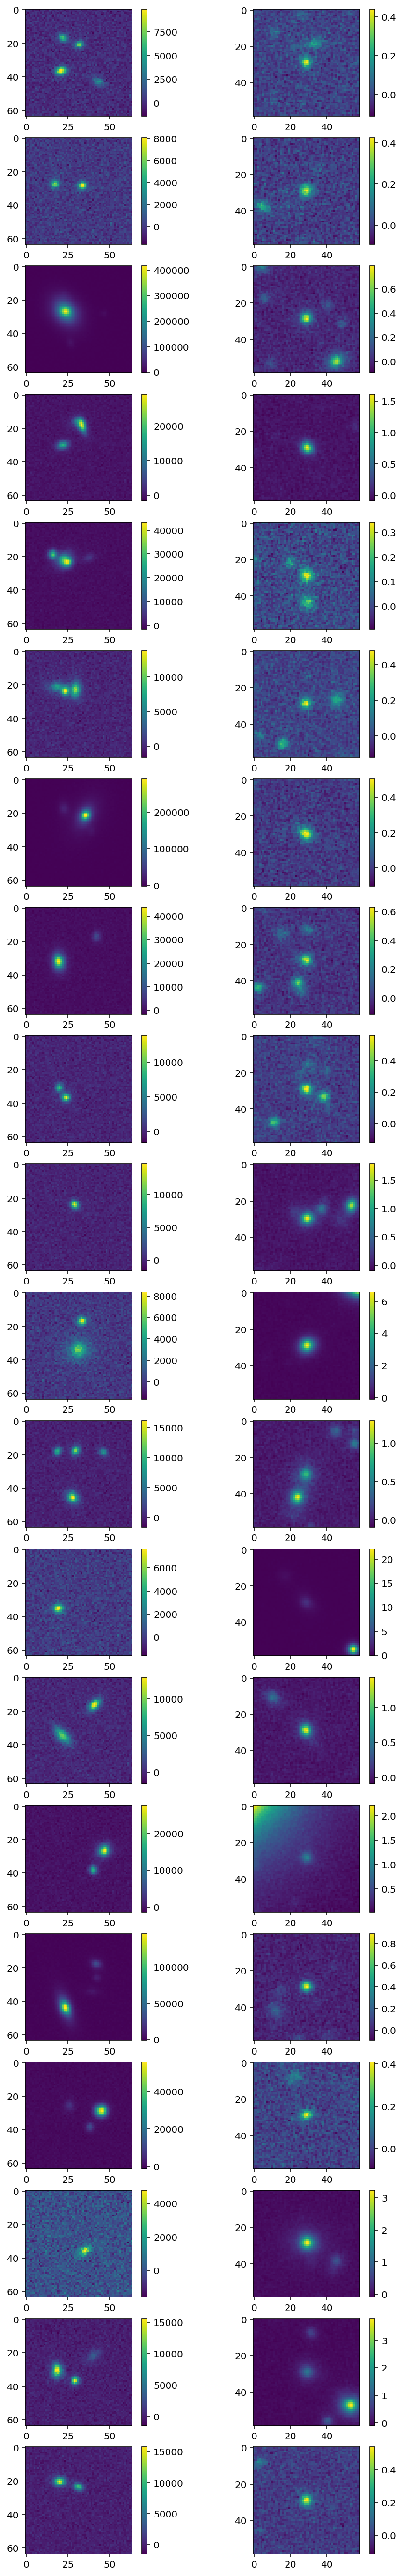

In [29]:
fig, axes = plt.subplots(20, 2, figsize=(8, 50))

for i in range (20):
    fig1 = axes[i,0].imshow(img_galsim[i,1,6])
    fig2 = axes[i,1].imshow(x_1_temp[i,:,:,2])
    fig.colorbar(fig1, ax=axes[i,0])
    fig.colorbar(fig2, ax=axes[i,1])

In [34]:
print(np.std(img_galsim[1,1,6,0:20,0:20]), np.std(x_1_temp[1,0:20,0:20,2]))
print(np.std(img_galsim[17,1,6,0:20,0:20]), np.std(x_1_temp[17,0:20,0:20,2]))
print(np.std(img_galsim[3,1,6,0:20,0:20]), np.std(x_1_temp[3,0:20,0:20,2]))
print(np.std(img_galsim[18,1,6,0:20,0:20]), np.std(x_1_temp[18,0:20,0:20,2]))

427.84752511116625 0.03062464245791806
416.5351329419885 0.03067011777054939
429.70794877887704 0.029801800327817145
440.28798864351273 0.03048424143579626


In [35]:
416/0.03

13866.666666666668

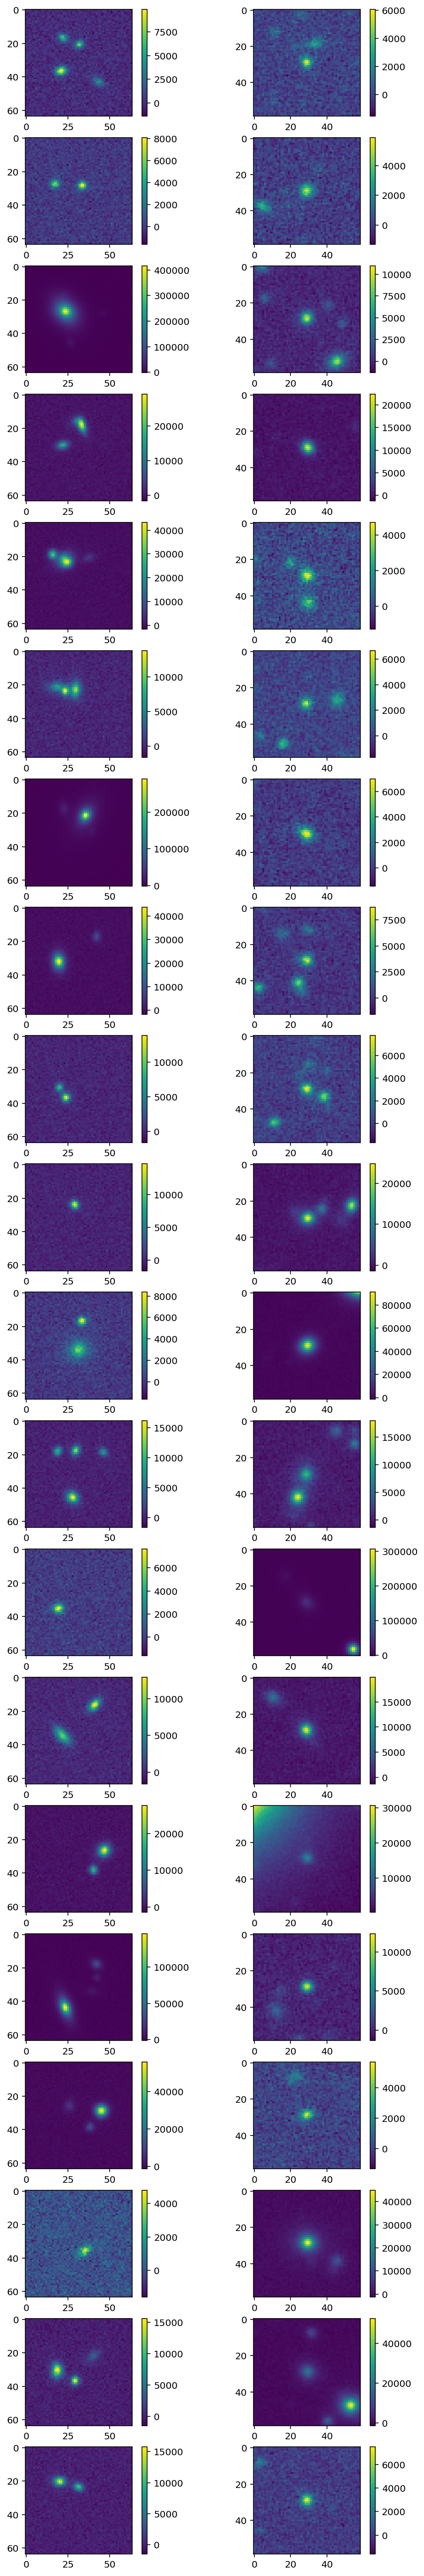

In [36]:
fig, axes = plt.subplots(20, 2, figsize=(8, 50))

for i in range (20):
    fig1 = axes[i,0].imshow(img_galsim[i,1,6])
    fig2 = axes[i,1].imshow(13866*x_1_temp[i,:,:,2])
    fig.colorbar(fig1, ax=axes[i,0])
    fig.colorbar(fig2, ax=axes[i,1])

In [50]:
test = pd.read_csv('/pbs/home/b/barcelin/sps_link/data/dc2_test/deconv_conv_24.5/validation/img_data.csv')

In [3]:
import keras_gcnn

In [24]:
reload(keras_gcnn)

<module 'keras_gcnn' from '/pbs/throng/lsst/users/barcelin/src/keras-gcnn/keras_gcnn/__init__.py'>

In [25]:
from keras_gcnn.layers import GConv2D

In [35]:
final_dim = 2
filters = [32,64,128,256]#,128,256]#[32,64,128,256]#[8,16,32,64]#[32,64,128,256]#,128]#[32,64,128,256,512]
kernels = [3,3,3,3]#[3,3,3,3]##,3]

from tensorflow.keras.layers import Input, Dense, Lambda, Layer, Add, Multiply, Reshape, Flatten, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import LocallyConnected2D, Conv2D, Conv3D, Input, Dense, Dropout, MaxPool2D, Flatten,  Reshape, UpSampling2D, Cropping2D, Conv2DTranspose, PReLU, Concatenate, Lambda, BatchNormalization, concatenate, LeakyReLU
import tensorflow_probability as tfp

In [44]:
def create_model_wo_ls_peak_3(input_shape, filters, kernels, final_dim, conv_activation=None, dense_activation=None):
    input_layer_1 = Input(shape=(64,64,6)) 
    input_layer_2 = Input(shape=(64,64,6)) 

    h = BatchNormalization()(input_layer_1)
    h_2 = input_layer_2
    #h = tf.keras.layers.concatenate([h, h_2], axis =-1)
    for i in range(len(filters)):
        h = Conv2D(filters[i], (kernels[i],kernels[i]), activation=None, padding='same')(h)
        h = PReLU()(h)
        h = Conv2D(filters[i], (kernels[i],kernels[i]), activation=None, padding='same', strides=(2,2))(h)
        h = PReLU()(h)
        #h = Dropout(0.25)(h)
    h = Flatten()(h)
    h = PReLU()(h)
    #h = Dense(64)(h)
    #h = PReLU()(h)
    h = Dense(tfp.layers.MultivariateNormalTriL.params_size(final_dim),activation=None)(h)
    h = tfp.layers.MultivariateNormalTriL(final_dim)(h)#,activity_regularizer=tfp.layers.KLDivergenceRegularizer(prior, weight=0.1))(h)

    model = Model([input_layer_1, input_layer_2],h)

    return model

In [45]:
net = create_model_wo_ls_peak_3((64,64,6),filters,kernels, final_dim)
net.summary()

Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_13 (InputLayer)           [(None, 64, 64, 6)]  0                                            
__________________________________________________________________________________________________
batch_normalization_6 (BatchNor (None, 64, 64, 6)    24          input_13[0][0]                   
__________________________________________________________________________________________________
conv2d_18 (Conv2D)              (None, 64, 64, 32)   1760        batch_normalization_6[0][0]      
__________________________________________________________________________________________________
p_re_lu_27 (PReLU)              (None, 64, 64, 32)   131072      conv2d_18[0][0]                  
____________________________________________________________________________________________

In [58]:
def create_model_wo_ls_peak_3(input_shape, filters, kernels, final_dim, conv_activation=None, dense_activation=None):
    input_layer_1 = Input(shape=(64,64,6)) 
    input_layer_2 = Input(shape=(64,64,6)) 

    h = BatchNormalization()(input_layer_1)
    h_2 = input_layer_2
    #h = tf.keras.layers.concatenate([h, h_2], axis =-1)
    for i in range(len(filters)):
        h = GConv2D(filters[i], (kernels[i],kernels[i]), activation=None, padding='same',h_input='Z2',h_output='C4')(h)
        h = PReLU()(h)
        h = GConv2D(filters[i], (kernels[i],kernels[i]), activation=None, padding='same', strides=(2,2), h_input='C4',h_output='C4')(h)
        h = PReLU()(h)
        #h = Dropout(0.25)(h)
    h = Flatten()(h)
    h = PReLU()(h)
    #h = Dense(64)(h)
    #h = PReLU()(h)
    h = Dense(tfp.layers.MultivariateNormalTriL.params_size(final_dim),activation=None)(h)
    h = tfp.layers.MultivariateNormalTriL(final_dim)(h)#,activity_regularizer=tfp.layers.KLDivergenceRegularizer(prior, weight=0.1))(h)

    model = Model([input_layer_1, input_layer_2],h)

    return model

In [59]:
net = create_model_wo_ls_peak_3((64,64,6),filters,kernels, final_dim)

In [60]:
net.summary()

Model: "model_6"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_23 (InputLayer)           [(None, 64, 64, 6)]  0                                            
__________________________________________________________________________________________________
batch_normalization_11 (BatchNo (None, 64, 64, 6)    24          input_23[0][0]                   
__________________________________________________________________________________________________
g_conv2d_33 (GConv2D)           (None, 64, 64, 128)  1728        batch_normalization_11[0][0]     
__________________________________________________________________________________________________
p_re_lu_59 (PReLU)              (None, 64, 64, 128)  524288      g_conv2d_33[0][0]                
____________________________________________________________________________________________